<H1> Feature Engineering </H1>

This notebook transforms raw creature data into engineered features for HP prediction.

**Input:** `data/dnd5e_monsters_from_json.csv`  
**Output:** `helper_files/engineered_features.parquet`

# Imports and Configs

## Python Imports

In [50]:
import json
import numpy as np
import os
import pandas as pd
import sys

from pathlib import Path


In [51]:
# %pip install pyarrow
# %pip install fastparquet

## Set Paths Dynamically

In [52]:
# Detect execution context and set paths dynamically

# Get the current working directory
cwd = Path.cwd()

# Check if we're in the notebooks directory or project root
if cwd.name == 'notebooks':
    # Running from notebooks directory (in Jupyter)
    DATA_DIR = '../data'
    PICKLED_MODELS_DIR = '../pickled_models'
    MONSTER_BUILDER_DIR = '../monster-builder-v2'
    HELPERS_DIR = './helper_files'
    IO_DIR = './notebooks_io'
    IN_NB_DIR = False
else:
    # Running from project root (via run_three_tier_model.py)
    DATA_DIR = './data'
    PICKLED_MODELS_DIR = './pickled_models'
    MONSTER_BUILDER_DIR = './monster-builder-v2'
    HELPERS_DIR = './notebooks/helper_files'
    IO_DIR = './notebooks/notebooks_io'
    IN_NB_DIR = False

print(f"📁 Execution context detected:")
print(f"   Current directory: {cwd}")
print(f"   Data directory: {DATA_DIR}")
print(f"   Models directory: {PICKLED_MODELS_DIR}")


📁 Execution context detected:
   Current directory: /workspaces/matrix_v0
   Data directory: ./data
   Models directory: ./pickled_models


## Add helper_files to path

In [53]:

# Add helper_files to path
# sys.path.insert(0, '.')
#
# claude: Imports are grouped by source module within helper_files/.
#   feature_config.py  → all CAPS constants, get_cr_tier, get_phase3_features
#   parsers.py         → all parse_*, has_*, calculate_*, extract_*, count_*, SIZE_ORDINAL_MAP
#   baseline_functions.py → all get_baseline_*, get_fly_speed_baseline, get_darkvision_baseline
#
# When adding a new helper function:
#   1. Define it in the appropriate module above
#   2. Export it in helper_files/__init__.py
#   3. Import it in BOTH branches below (IN_NB_DIR True / False)

if IN_NB_DIR is True:
    from helper_files import (
        # Config — from feature_config.py
        CONDITIONS, DMG_FEATURE_NAMES, PHASE2_FEATURES, PHASE2_PENALTIES,
        get_cr_tier, get_phase3_features,
        DMG_ADVANTAGE_OVERRIDES, DMG_ATTACKERS_ADVANTAGE_OVERRIDES,
        # Parsers — from parsers.py
        parse_cr, parse_hp, parse_ac, parse_speed, SIZE_ORDINAL_MAP,
        count_proficiencies, has_sense, parse_sense_range, parse_passive_perception,
        count_abilities, parse_legendary_actions, parse_attack_bonus, parse_save_dc,
        parse_dpr_from_json, parse_charge_bonus_attack, parse_legendary_actions_dpr,
        parse_legendary_conditions,
        has_advantage_condition, has_disadvantage_condition, has_attackers_advantage,
        parse_dmg_features, calculate_feature_ac, calculate_feature_attack,
        calculate_feature_dpr, parse_breath_weapon_dpr, parse_trait_extra_dpr,
        calculate_feature_hp,
        get_resistance_multiplier, get_immunity_multiplier, extract_family,
        # Baselines — from baseline_functions.py
        get_baseline_hp, get_baseline_ac, get_baseline_attack, get_baseline_dpr,
        get_baseline_dc, get_baseline_size_ordinal, get_baseline_speed_ground,
        get_fly_speed_baseline, get_darkvision_baseline,
    )
    # lazy 5e baselines (parsers.py — used only for loading/adjusting lazy_5e CSV)
    from helper_files import (
        parse_hp_avg, parse_bonus, adjust_hp_baseline
    )

    print("Imports successful")
else:
    from notebooks.helper_files import (
        # Config — from feature_config.py
        CONDITIONS, DMG_FEATURE_NAMES, PHASE2_FEATURES, PHASE2_PENALTIES,
        get_cr_tier, get_phase3_features,
        DMG_ADVANTAGE_OVERRIDES, DMG_ATTACKERS_ADVANTAGE_OVERRIDES,
        # Parsers — from parsers.py
        parse_cr, parse_hp, parse_ac, parse_speed, SIZE_ORDINAL_MAP,
        count_proficiencies, has_sense, parse_sense_range, parse_passive_perception,
        count_abilities, parse_legendary_actions, parse_attack_bonus, parse_save_dc,
        parse_dpr_from_json, parse_charge_bonus_attack, parse_legendary_actions_dpr,
        parse_legendary_conditions,
        has_advantage_condition, has_disadvantage_condition, has_attackers_advantage,
        parse_dmg_features, calculate_feature_ac, calculate_feature_attack,
        calculate_feature_dpr, parse_breath_weapon_dpr, parse_trait_extra_dpr,
        calculate_feature_hp,
        get_resistance_multiplier, get_immunity_multiplier, extract_family,
        # Baselines — from baseline_functions.py
        get_baseline_hp, get_baseline_ac, get_baseline_attack, get_baseline_dpr,
        get_baseline_dc, get_baseline_size_ordinal, get_baseline_speed_ground,
        get_fly_speed_baseline, get_darkvision_baseline,
    )
    # lazy 5e baselines (parsers.py)
    from notebooks.helper_files import (
        parse_hp_avg, adjust_hp_baseline, parse_bonus
    )

    print("Imports successful")


Imports successful


# Load Raw Data

In [54]:
# Load main creature data
df = pd.read_csv(f'{DATA_DIR}/dnd5e_monsters_from_json.csv')
print(f"Loaded {len(df)} monsters")
print(f"Columns: {list(df.columns)[:10]}...")


# Filter to only 2014 (original 5e) monsters - exclude 2024 additions
df = df[df['Source_Name'] == 'Free Basic Rules (2014)'].copy()
print(f"📊 Loaded {len(df)} monsters (2014 5e only, excluding 2024 additions)")

# Load Lazy 5e baseline stats
lazy_5e = pd.read_csv(f'{DATA_DIR}/lazy_5e_monster_stats_by_cr.csv')
print(f"📊 Loaded {len(lazy_5e)} CR baselines from Lazy 5e")

# print("\n🔍 Lazy 5e Baseline Stats Preview:")
# display(lazy_5e.head(10))

# Load Spellcasting features
load_path = DATA_DIR + '/spellcaster_spell_features.csv'
df_spellcaster_features = pd.read_csv(load_path)
print(f"📊 Loaded {len(df_spellcaster_features)} Spellcasters")


Loaded 382 monsters
Columns: ['Name', 'Size', 'Type', 'Alignment', 'HP', 'AC', 'Speed', 'Challenge_Rating', 'XP', 'STR']...
📊 Loaded 324 monsters (2014 5e only, excluding 2024 additions)
📊 Loaded 34 CR baselines from Lazy 5e
📊 Loaded 36 Spellcasters


In [55]:
# === CONDITION DEFINITIONS (D&D 5e) ===
# Source: https://roll20.net/compendium/dnd5e/Conditions
# These definitions inform how we value condition-inflicting abilities
#
# claude: This dict is INFORMATIONAL ONLY — it is not used in any computation.
# The actual list of conditions used for inflicts_{condition} column generation
# is CONDITIONS in feature_config.py (currently 10 conditions).
# If you add a condition there, consider adding it here too for reference.

CONDITION_DEFINITIONS = {
    'blinded': {
        'description': "Can't see, auto-fails sight-based checks. Attacks against have advantage, its attacks have disadvantage.",
        'severity': 'high',  # Significant combat impact
    },
    'charmed': {
        'description': "Can't attack or harm the charmer. Charmer has advantage on social checks.",
        'severity': 'medium',  # Situational, doesn't affect all enemies
    },
    'deafened': {
        'description': "Can't hear, auto-fails hearing-based checks.",
        'severity': 'low',  # Minimal combat impact
    },
    'frightened': {
        'description': "Disadvantage on ability checks and attacks while source visible. Can't willingly approach source.",
        'severity': 'medium',  # Good debuff but conditional
    },
    'grappled': {
        'description': "Speed becomes 0, can't benefit from speed bonuses. Ends if grappler incapacitated.",
        'severity': 'medium',  # Locks down movement
    },
    'incapacitated': {
        'description': "Can't take actions or reactions.",
        'severity': 'high',  # Complete action denial
    },
    'paralyzed': {
        'description': "Incapacitated, can't move or speak. Auto-fails STR/DEX saves. Attacks have advantage, crits within 5ft.",
        'severity': 'very_high',  # Devastating - combines multiple effects
    },
    'petrified': {
        'description': "Turned to stone. Incapacitated, resistant to all damage, immune to poison/disease.",
        'severity': 'very_high',  # Effectively removes from combat
    },
    'poisoned': {
        'description': "Disadvantage on attack rolls and ability checks.",
        'severity': 'medium',  # Consistent debuff
    },
    'prone': {
        'description': "Must crawl to move. Attacks have disadvantage. Melee attacks against have advantage, ranged have disadvantage.",
        'severity': 'low',  # Easy to recover from (half movement)
    },
    'restrained': {
        'description': "Speed 0. Attacks against have advantage, its attacks have disadvantage. DEX saves have disadvantage.",
        'severity': 'high',  # Strong control + offensive debuff
    },
    'stunned': {
        'description': "Incapacitated, can't move, speaks falteringly. Auto-fails STR/DEX saves. Attacks against have advantage.",
        'severity': 'very_high',  # Near-paralysis
    },
    'unconscious': {
        'description': "Incapacitated, can't move/speak, unaware. Drops items, falls prone. Attacks are crits within 5ft.",
        'severity': 'very_high',  # Complete incapacitation
    },
}

# Severity rankings for reference:
# very_high: paralyzed, petrified, stunned, unconscious (target is essentially out of combat)
# high: blinded, incapacitated, restrained (major combat impairment)
# medium: charmed, frightened, grappled, poisoned (significant but conditional/recoverable)
# low: deafened, prone (minimal or easily recovered)

print("Condition Definitions Loaded:")
for condition, info in CONDITION_DEFINITIONS.items():
    print(f"   {condition:15s} [{info['severity']:9s}]: {info['description'][:60]}...")

Condition Definitions Loaded:
   blinded         [high     ]: Can't see, auto-fails sight-based checks. Attacks against ha...
   charmed         [medium   ]: Can't attack or harm the charmer. Charmer has advantage on s...
   deafened        [low      ]: Can't hear, auto-fails hearing-based checks....
   frightened      [medium   ]: Disadvantage on ability checks and attacks while source visi...
   grappled        [medium   ]: Speed becomes 0, can't benefit from speed bonuses. Ends if g...
   incapacitated   [high     ]: Can't take actions or reactions....
   paralyzed       [very_high]: Incapacitated, can't move or speak. Auto-fails STR/DEX saves...
   petrified       [very_high]: Turned to stone. Incapacitated, resistant to all damage, imm...
   poisoned        [medium   ]: Disadvantage on attack rolls and ability checks....
   prone           [low      ]: Must crawl to move. Attacks have disadvantage. Melee attacks...
   restrained      [high     ]: Speed 0. Attacks against have adva

# Actual Feature Engineering

## Parse Basic Features

### Baselines

In [56]:
# Convert Lazy 5e CR to numeric
lazy_5e['cr_numeric'] = lazy_5e['CR'].apply(parse_cr)


# Parse HP from Lazy 5e (extract average from "65 (49-81)" format)
lazy_5e['hp_baseline'] = lazy_5e['HP'].apply(parse_hp_avg)

# Adjust HP baselines: +50% for CR <= 1, +20% for CR >= 2
lazy_5e['hp_baseline'] = lazy_5e.apply(adjust_hp_baseline, axis=1)
print("✅ Adjusted HP baselines: +50% for CR ≤ 1, +20% for CR ≥ 2")

# Parse Attack Bonus - handles both numeric (3) and "+3" format
lazy_5e['attack_baseline'] = lazy_5e['Attack_Bonus'].apply(parse_bonus)
lazy_5e['ac_baseline'] = lazy_5e['AC_DC']
lazy_5e['dpr_baseline'] = lazy_5e['Damage_Round']

print("✅ Parsed Lazy 5e baselines")


# Add size_ordinal baseline (Medium for CR < 12, Large for CR >= 12)
lazy_5e['size_ordinal_baseline'] = lazy_5e['cr_numeric'].apply(
    lambda cr: 2 if cr < 12 else 3  # 2 = Medium, 3 = Large
)

# Add speed baselines (constant 30 for all CR)
lazy_5e['speed_ground_baseline'] = 30
lazy_5e['max_speed_baseline'] = 30

print("✅ Added size_ordinal, speed_ground, and max_speed baselines")

print("\n📊 Baseline Stats by CR:")
display(lazy_5e[['cr_numeric', 'hp_baseline', 'ac_baseline', 'attack_baseline', 'dpr_baseline']].head(15))

✅ Adjusted HP baselines: +50% for CR ≤ 1, +20% for CR ≥ 2
✅ Parsed Lazy 5e baselines
✅ Added size_ordinal, speed_ground, and max_speed baselines

📊 Baseline Stats by CR:


,cr_numeric,hp_baseline,ac_baseline,attack_baseline,dpr_baseline
0,0.000,4.5,10,2,2
1,0.125,13.5,11,3,3
2,0.250,19.5,11,3,5
3,0.500,33.0,12,4,8
4,1.000,49.5,12,5,12
5,2.000,54.0,13,5,17
6,3.000,78.0,13,5,23
7,4.000,100.8,14,6,28
8,5.000,114.0,15,7,35
9,6.000,134.4,15,7,41


In [57]:
# Create interpolation functions for baselines
# cr_values = lazy_5e['cr_numeric'].values
# hp_baseline_interp = interp1d(cr_values, lazy_5e['hp_baseline'].values, 
#                                kind='linear', bounds_error=False, fill_value='extrapolate')
# ac_baseline_interp = interp1d(cr_values, lazy_5e['ac_baseline'].values,
#                                kind='linear', bounds_error=False, fill_value='extrapolate')
# attack_baseline_interp = interp1d(cr_values, lazy_5e['attack_baseline'].values,
#                                    kind='linear', bounds_error=False, fill_value='extrapolate')
# dpr_baseline_interp = interp1d(cr_values, lazy_5e['dpr_baseline'].values,
#                                 kind='linear', bounds_error=False, fill_value='extrapolate')
# # DC baseline uses same values as AC (from AC_DC column)
# dc_baseline_interp = interp1d(cr_values, lazy_5e['ac_baseline'].values,
#                                kind='linear', bounds_error=False, fill_value='extrapolate')


# # Size ordinal baseline (step function at CR 12)
# size_ordinal_baseline_interp = interp1d(
#     cr_values,
#     lazy_5e['size_ordinal_baseline'].values,
#     kind='previous',  # Use step function instead of linear
#     bounds_error=False,
#     fill_value=(2, 3)  # Medium below range, Large above range
# )
# print("✅ Created baseline interpolation functions")

### Main df

#### Core - CR, AC, HP

In [58]:
# Parse CR
df['cr_numeric'] = df['Challenge_Rating'].apply(parse_cr)

# Parse HP
df['actual_hp'] = df['HP'].apply(parse_hp)

# Parse AC
df['ac_value'] = df['AC'].apply(parse_ac)

print(f"CR range: {df['cr_numeric'].min()} - {df['cr_numeric'].max()}")
print(f"HP range: {df['actual_hp'].min()} - {df['actual_hp'].max()}")

CR range: 0.0 - 30.0
HP range: 1 - 676


#### Speeds

In [59]:
# Parse speeds
df['speed_ground'] = df['Speed'].apply(lambda x: parse_speed(x, 'ground'))
df['speed_fly'] = df['Speed'].apply(lambda x: parse_speed(x, 'fly'))
df['speed_swim'] = df['Speed'].apply(lambda x: parse_speed(x, 'swim'))
df['speed_burrow'] = df['Speed'].apply(lambda x: parse_speed(x, 'burrow'))
df['speed_climb'] = df['Speed'].apply(lambda x: parse_speed(x, 'climb'))

df['max_speed'] = df[['speed_ground', 'speed_fly', 'speed_swim', 'speed_burrow', 'speed_climb']].max(axis=1)
# Doing a minus 1 to not count ground speed
df['movement_types_count'] = (df[['speed_ground', 'speed_fly', 'speed_swim', 'speed_burrow', 'speed_climb']] > 0).sum(axis=1) - 1
df['has_flying'] = (df['speed_fly'] > 0).astype(int)


<Axes: xlabel='cr_numeric'>

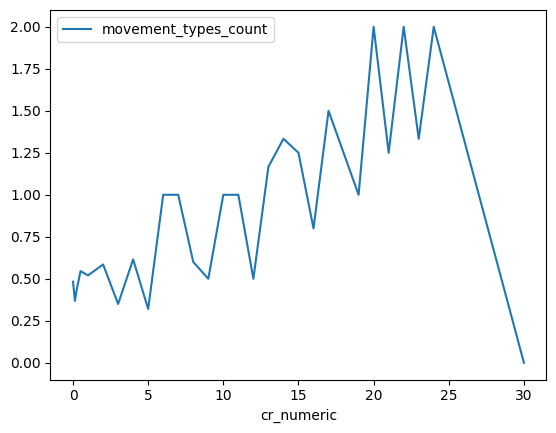

In [60]:
# Eventually, calculate from baseline. Higher CR buckets (over 10) are expected to have more movement types.
df[['movement_types_count', 'cr_numeric']].groupby('cr_numeric').mean().plot()

#### Size

In [61]:
# Parse size
df['size_ordinal'] = df['Size'].map(SIZE_ORDINAL_MAP).fillna(2)

#### Proficiencies

In [62]:
# Parse proficiencies
df['save_proficiency_count'] = df['Saving_Throws'].apply(count_proficiencies)
df['skill_proficiency_count'] = df['Skills'].apply(count_proficiencies)
df['resistance_count'] = df['Resistances'].apply(count_proficiencies)
df['immunity_count'] = df['Immunities'].apply(count_proficiencies)
df['vulnerability_count'] = df['Vulnerabilities'].apply(count_proficiencies)
df['condition_immunity_count'] = df['Condition_Immunities'].apply(count_proficiencies)

print("Proficiencies parsed")

Proficiencies parsed


#### Senses

In [63]:
# Parse senses
df['has_darkvision'] = df['Senses'].apply(lambda x: has_sense(x, 'darkvision'))
df['darkvision_range'] = df['Senses'].apply(lambda x: parse_sense_range(x, 'darkvision'))
df['has_blindsight'] = df['Senses'].apply(lambda x: has_sense(x, 'blindsight'))
df['has_truesight'] = df['Senses'].apply(lambda x: has_sense(x, 'truesight'))
df['has_tremorsense'] = df['Senses'].apply(lambda x: has_sense(x, 'tremorsense'))
df['passive_perception'] = df['Senses'].apply(parse_passive_perception)

print("Senses parsed")

Senses parsed


#### Abilities and Legendary Count

In [64]:
# Parse ability counts
# df['trait_count'] = df['Traits'].apply(count_abilities)
# df['action_count'] = df['Actions'].apply(count_abilities)
# df['reaction_count'] = df['Reactions'].apply(count_abilities)
# df['bonus_action_count'] = df['Bonus_Actions'].apply(count_abilities) if 'Bonus_Actions' in df.columns else 0

# Legendary actions
df[['has_legendary_actions', 'legendary_action_count', 'legendary_actions_per_round']] = df['Legendary_Actions'].apply(
    lambda x: pd.Series(parse_legendary_actions(x))
)

# df['total_ability_count'] = df['trait_count'] + df['action_count'] + df['reaction_count'] + df['legendary_action_count']

print("Ability counts parsed")

Ability counts parsed


## Parse Combat Stats

### Attack Bonus

In [65]:
# Parse attack bonus
df['highest_attack_bonus'] = df['Actions'].apply(parse_attack_bonus)

### Save DC and Overrides

In [66]:

# Parse save DC
# claude: combined_abilities concatenates Traits + Actions + Reactions + Legendary_Actions
# into a single text blob for keyword searching. Used by many cells below.
combined_abilities = (df['Traits'].fillna('') + ' ' + df['Actions'].fillna('') + ' ' +
                     df['Reactions'].fillna('') + ' ' + df['Legendary_Actions'].fillna(''))
df['highest_save_dc'] = combined_abilities.apply(parse_save_dc)
# Defined in: parsers.py → parse_save_dc()

# DC Overrides: manually correct creatures whose highest DC comes from a
# non-combat ability (e.g. Green Hag's DC 20 Illusory Appearance).
# Add entries here when a creature's thematic DC inflates its combat DC.
DC_OVERRIDES = {
    'Green Hag': 14,  # DC 20 is for Illusory Appearance (thematic, not combat)
}
for creature, dc in DC_OVERRIDES.items():
    df.loc[df['Name'] == creature, 'highest_save_dc'] = dc

print(f"Applied {len(DC_OVERRIDES)} DC overrides")

Applied 1 DC overrides


### DPRs

In [67]:
# Parse DPR (4-layer: estimated + feature + legendary = total)
# See notebooks/CONTEXT.md "4-Layer Column Convention" for the full pattern.
#
# claude: DPR follows the 4-layer convention (estimated / feature / legendary / total).
#   estimated_dpr: Best per-round attack damage from Actions JSON.
#       Breath weapons are EXCLUDED — their damage is in the Desc field, not Damage field.
#       Defined in: parsers.py → parse_dpr_from_json()
#   feature_dpr: One-time burst damage (charge/pounce/rampage) amortised over 3 rounds.
#       Divisor is EXPECTED_COMBAT_ROUNDS in feature_config.py.
#       Defined in: parsers.py → parse_charge_bonus_attack()
#   legendary_dpr: Damage from legendary actions.
#       Defined in: parsers.py → parse_legendary_actions_dpr()

df['estimated_dpr'] = df['Actions'].apply(parse_dpr_from_json)

# Feature DPR: burst damage from charge/pounce/rampage (amortized over 3 rounds)
df['feature_dpr'] = df.apply(lambda row: parse_charge_bonus_attack(row['Traits'], row['Actions']), axis=1)

# Parse legendary DPR
df['legendary_dpr'] = df['Legendary_Actions'].apply(parse_legendary_actions_dpr)

# Total DPR = estimated + feature + legendary
df['total_dpr'] = df['estimated_dpr'] + df['feature_dpr'] + df['legendary_dpr']

print(f"DPR range: {df['total_dpr'].min():.1f} - {df['total_dpr'].max():.1f}")
print(f"Creatures with feature_dpr > 0: {(df['feature_dpr'] > 0).sum()}")

DPR range: 0.0 - 185.3
Creatures with feature_dpr > 0: 20


## Parse Special Traits

### Special traits from combined abilities

In [68]:
# Special traits from combined abilities
# claude: These are raw boolean detection flags. has_magic_resistance here is a
# simple keyword match — the DMG-specified AC cost (+2) is handled separately
# by feature_magic_resistance in the DMG Feature Costing section (cell 58).
# has_magic_resistance is still used to compute has_magic_resistance_scaled in
# older references but was REMOVED from Phase 3 features — the cost now flows
# through feature_ac → ac_deviation instead.
df['has_legendary_resistance'] = combined_abilities.str.contains('legendary resistance', case=False, na=False).astype(int)
df['has_magic_resistance'] = combined_abilities.str.contains('magic resistance', case=False, na=False).astype(int)
df['has_regeneration'] = combined_abilities.str.contains('regeneration', case=False, na=False).astype(int)
df['has_grapple'] = combined_abilities.str.contains('grapple|grappled', case=False, na=False).astype(int)
print("Special traits parsed")


Special traits parsed


### Inflicts Conditions

In [69]:
# Parse legendary conditions
df['legendary_conditions'] = df['Legendary_Actions'].apply(parse_legendary_conditions)

In [70]:
# Condition infliction features
# claude: CONDITIONS list is defined in feature_config.py (currently 10 conditions).
# This loop auto-generates inflicts_{condition} columns for each.
# Adding a new condition to the CONDITIONS list auto-propagates here,
# to get_phase3_features(), and to get_export_columns().
for condition in CONDITIONS:
    feature_name = f'inflicts_{condition}'
    df[feature_name] = combined_abilities.str.contains(condition, case=False, na=False).astype(int)
    # Also check legendary actions
    df[feature_name] = df.apply(
        lambda row: 1 if (row[feature_name] == 1 or condition in row['legendary_conditions']) else 0,
        axis=1
    )

# Inflicts prone (Phase 2 feature — handled separately because prone is not in CONDITIONS)
df['inflicts_prone'] = combined_abilities.str.contains('prone', case=False, na=False).astype(int)
df['inflicts_prone'] = df.apply(
    lambda row: 1 if (row['inflicts_prone'] == 1 or 'prone' in row['legendary_conditions']) else 0,
    axis=1
)

print(f"{len(CONDITIONS)} condition features added")
print(f"Creatures that inflict prone: {df['inflicts_prone'].sum()} ({df['inflicts_prone'].mean()*100:.1f}%)")

10 condition features added
Creatures that inflict prone: 64 (19.8%)


### Advantage/disadvantage conditions

In [71]:
# Advantage/disadvantage conditions
# claude: These are GENERIC detection flags — they detect ANY source of advantage/disadvantage
# from hardcoded keyword lists in parsers.py.
#   Defined in: parsers.py → has_advantage_condition(), has_disadvantage_condition(), has_attackers_advantage()
#
# In the DMG Feature Costing section (cell 58), specific classified features
# (e.g. pack_tactics, blood_frenzy, reckless) OVERRIDE these flags to 0.
# After overrides, these flags mean "advantage from an UNCLASSIFIED source."
# Override lists: DMG_ADVANTAGE_OVERRIDES, DMG_ATTACKERS_ADVANTAGE_OVERRIDES in feature_config.py
df['has_advantage_condition'] = df.apply(has_advantage_condition, axis=1)
df['has_disadvantage_condition'] = df.apply(has_disadvantage_condition, axis=1)
df['has_attackers_advantage'] = df.apply(has_attackers_advantage, axis=1)

print(f"Advantage conditions: {df['has_advantage_condition'].sum()} ({df['has_advantage_condition'].mean()*100:.1f}%)")
print(f"Disadvantage conditions: {df['has_disadvantage_condition'].sum()} ({df['has_disadvantage_condition'].mean()*100:.1f}%)")

Advantage conditions: 32 (9.9%)
Disadvantage conditions: 9 (2.8%)


## Spellcasting

NB - this section must go *after* all other feature identification but *before* Calculate Deviations

In [72]:
# Detect spellcasting features based on generic identification
df['has_spellcasting'] = combined_abilities.str.contains('spellcasting', case=False, na=False).astype(int)

In [73]:
print(f"found {df[df['has_spellcasting']==1].shape[0]} spellcasters")
print(f"features available for {df_spellcaster_features.shape[0]} spellcasters")

print('\nSpellcasters missing features:')
print([mon for mon in list(df[df['has_spellcasting']==1]['Name']) if mon not in df_spellcaster_features['Name'].values])

found 36 spellcasters
features available for 36 spellcasters

Spellcasters missing features:
[]


In [74]:
# Isolate spellcasters and create mergeable DataFrames with consistent column names
# claude: spellcaster_spell_features.csv has different column names than main df.
# This dict maps CSV column names → main df column names so we can merge via max().
#
# IMPORTANT: combat_dpr maps to estimated_dpr (not total_dpr) because cell 58 recalculates
# total_dpr = estimated_dpr + feature_dpr + legendary_dpr. By setting estimated_dpr to
# max(melee, spell_combat_dpr), the spell DPR survives the recalculation.
#
# spell_ac_bonus and spell_feature_* are applied AFTER cell 58 (DMG Feature Costing)
# because cell 58 overwrites feature_ac and feature_{name} from scratch.
spellcasting_rename_dict = {
    'combat_dpr':  'estimated_dpr',
    'grants_flying': 'has_flying',
    'attack_bonus': 'highest_attack_bonus',
    'save_bonus': 'highest_save_dc',
    'grants_advantage': 'has_advantage_condition',
    'inflicts_disadvantage': 'has_disadvantage_condition',
}

# Extract spell-specific columns BEFORE rename (applied after cell 58)
spell_ac_bonus = df_spellcaster_features.set_index('Name')['spell_ac_bonus'] if 'spell_ac_bonus' in df_spellcaster_features.columns else None
spell_feature_invis = df_spellcaster_features.set_index('Name')['spell_feature_invisibility'] if 'spell_feature_invisibility' in df_spellcaster_features.columns else None
spell_feature_sup_invis = df_spellcaster_features.set_index('Name')['spell_feature_superior_invisibility'] if 'spell_feature_superior_invisibility' in df_spellcaster_features.columns else None

# Drop spell-specific columns before rename (they don't map to existing main df columns)
cols_to_drop = [c for c in ['spell_ac_bonus', 'spell_feature_invisibility', 'spell_feature_superior_invisibility'] if c in df_spellcaster_features.columns]
df_spellcaster_features = df_spellcaster_features.drop(columns=cols_to_drop)

# Rename remaining columns
df_spellcaster_features = df_spellcaster_features.rename(columns=spellcasting_rename_dict)

def identify_spellcasters(row):
    return row['has_spellcasting'] == 1

df_spellcasters = df[df.apply(identify_spellcasters, axis=1)].copy()

# Set 'Name' as index for both DataFrames (safely, account for repeated runs)
if df_spellcaster_features.index.name != 'Name':
    df_spellcaster_features = df_spellcaster_features.set_index('Name')
if df_spellcasters.index.name != 'Name':
    df_spellcasters = df_spellcasters.set_index('Name')

In [75]:
df_spellcasters.loc['Cult Fanatic', 'total_dpr']

np.float64(9.0)

In [76]:
df_spellcaster_features.loc['Cult Fanatic', 'estimated_dpr']

np.float64(16.5)

In [77]:
# --- MAX merge: update df_spellcasters with max of (existing, spell feature) ---
# This covers renamed columns (estimated_dpr, has_flying, highest_attack_bonus, etc.)
# and same-named columns (inflicts_* conditions).
#
# NOTE: spell_ac_bonus and spell feature flags (invisibility, superior_invisibility)
# are applied AFTER cell 58 (DMG Feature Costing) because cell 58 overwrites
# feature_ac and feature_{name} from scratch.
for col in df_spellcaster_features.columns:
    if col in df_spellcasters.columns:
        df_spellcasters[col] = df_spellcasters[col].combine(df_spellcaster_features[col], max)

# --- FLYING: set speed_fly to 60 if spell grants flying ---
_has_flying = df_spellcaster_features['has_flying'] == True
_lesser_flyspeed = df_spellcasters['speed_fly'] < 60
_condition = _has_flying & _lesser_flyspeed
df_spellcasters.loc[_condition.index & _condition, 'speed_fly'] = 60

# Reset index to allow for rejoining with main df later
df_spellcasters = df_spellcasters.reset_index()

In [78]:
# Consider doing a spellcaster level baseline
# df_spellcasters[['spellcaster_level', 'cr_numeric']].groupby('cr_numeric').mean()

In [79]:
_monster = 'Cult Fanatic'
_to_print = df[df['Name']==_monster].iloc[0]
_to_print_fts = df_spellcasters[df_spellcasters['Name']==_monster].iloc[0]
for k, v in _to_print.items():
    if k in df_spellcaster_features.columns:
        print(f"{k:30s}: {v} {_to_print_fts[k]}")
# NOTE: spell_ac_bonus and spell feature flags are applied after cell 58 (DMG Feature Costing).
# See the cell after cell 58 for those adjustments.

has_flying                    : 0 0
highest_attack_bonus          : 4 4.0
highest_save_dc               : 11 11
estimated_dpr                 : 9.0 16.5
inflicts_poisoned             : 0 0
inflicts_blinded              : 0 0
inflicts_charmed              : 1 1
inflicts_deafened             : 0 0
inflicts_frightened           : 1 1
inflicts_incapacitated        : 0 0
inflicts_paralyzed            : 0 1
inflicts_petrified            : 0 0
inflicts_restrained           : 0 0
inflicts_stunned              : 0 0
inflicts_prone                : 0 0
has_advantage_condition       : 0 0
has_disadvantage_condition    : 0 0


In [80]:
# Re-merge spellcasters back into main df
REMERGE_SPELLCASTER = True
if REMERGE_SPELLCASTER:
    df = df[~df.apply(lambda x: identify_spellcasters(x), axis=1)]
    df = pd.concat([df, df_spellcasters], ignore_index=True)

## DMG Feature Costing

Detect DMG Monster Features (pp.280-281) that specify effective AC or attack bonus adjustments.
Each detected feature gets a `feature_{name}` column. Aggregated adjustments feed into `feature_ac` and `feature_attack`.
Generic flags (`has_advantage_condition`, `has_attackers_advantage`) are overridden to 0 when a specific DMG feature explains the ability.

In [81]:
# DMG Feature Detection and Costing
#
# claude: This cell does four things:
#   1. DETECT: Scan traits/actions for 92 DMG features → feature_{name} flag columns (0/1)
#      Defined in: parsers.py → parse_dmg_features()
#      Feature list: feature_config.py → DMG_FEATURE_NAMES
#
#   2. AGGREGATE AC/ATTACK: Sum AC and attack adjustments from detected features
#      feature_ac  = Σ(DMG_AC_ADJUSTMENTS[feat]) for each detected feature
#      feature_attack = Σ(DMG_ATTACK_ADJUSTMENTS[feat]) for each detected feature
#      Defined in: parsers.py → calculate_feature_ac(), calculate_feature_attack()
#
#   3. AGGREGATE DPR: Add fixed per-round DPR, breath weapon excess, and trait extra damage
#      feature_dpr += calculate_feature_dpr()  (fixed DPR from DMG_DPR_ADJUSTMENTS)
#      feature_dpr += parse_breath_weapon_dpr()  (breath weapon excess over multiattack)
#      feature_dpr += parse_trait_extra_dpr()  (sneak attack, martial advantage, etc.)
#      Recalculate total_dpr with all sources.
#
#   4. OVERRIDE: Zero out generic advantage flags where a specific DMG feature is detected.
#      Override lists: feature_config.py → DMG_ADVANTAGE_OVERRIDES, DMG_ATTACKERS_ADVANTAGE_OVERRIDES
#
# NOTE: feature_hp is calculated in cell 71 (Phase 1) AFTER baselines are computed,
# because it depends on hp_baseline for percentage/multiplier features.
#
# To add a new DMG feature, see the checklist in notebooks/CONTEXT.md.

# Detect DMG features (feature_{name} flags)
dmg_features = df.apply(parse_dmg_features, axis=1, result_type='expand')
for col in dmg_features.columns:
    df[col] = dmg_features[col]

# Calculate aggregated AC and attack adjustments from DMG features
df['feature_ac'] = df.apply(calculate_feature_ac, axis=1)
df['feature_attack'] = df.apply(calculate_feature_attack, axis=1)

# DPR: Add fixed per-round DPR from DMG_DPR_ADJUSTMENTS (e.g. aggressive +2, rampage +2)
df['feature_dpr'] += df.apply(calculate_feature_dpr, axis=1)

# DPR: Add breath weapon excess over multiattack (2 targets, each fails save per DMG)
df['feature_dpr'] += df.apply(parse_breath_weapon_dpr, axis=1)

# DPR: Add per-round trait damage (sneak attack, martial advantage, elemental body)
df['feature_dpr'] += df.apply(parse_trait_extra_dpr, axis=1)

# Recalculate total_dpr with all DPR sources
df['total_dpr'] = df['estimated_dpr'] + df['feature_dpr'] + df['legendary_dpr']

# Override generic flags when a specific DMG feature explains the ability
for feat in DMG_ADVANTAGE_OVERRIDES:
    col = f'feature_{feat}'
    if col in df.columns:
        df.loc[df[col] == 1, 'has_advantage_condition'] = 0
for feat in DMG_ATTACKERS_ADVANTAGE_OVERRIDES:
    col = f'feature_{feat}'
    if col in df.columns:
        df.loc[df[col] == 1, 'has_attackers_advantage'] = 0

# Calculate totals (estimated + feature adjustments)
# These follow the 4-layer convention: estimated + feature = total
# (AC and attack don't have a legendary layer)
df['total_ac'] = df['ac_value'] + df['feature_ac']
df['total_attack'] = df['highest_attack_bonus'] + df['feature_attack']

# Summary
detected_count = sum(1 for col in dmg_features.columns if df[col].sum() > 0)
print(f"DMG features detected: {detected_count} features across creatures")
for col in sorted(dmg_features.columns):
    count = df[col].sum()
    if count > 0:
        print(f"  {col}: {count} creatures")
print(f"\nAggregated adjustments:")
print(f"  Creatures with feature_ac > 0: {(df['feature_ac'] > 0).sum()}")
print(f"  Creatures with feature_attack > 0: {(df['feature_attack'] > 0).sum()}")
print(f"  Creatures with feature_dpr > 0: {(df['feature_dpr'] > 0).sum()}")
print(f"\nOverride summary:")
print(f"  has_advantage_condition (after overrides): {df['has_advantage_condition'].sum()}")
print(f"  has_attackers_advantage (after overrides): {df['has_attackers_advantage'].sum()}")


DMG features detected: 77 features across creatures
  feature_aggressive: 1 creatures
  feature_ambusher: 1 creatures
  feature_amorphous: 4 creatures
  feature_amphibious: 30 creatures
  feature_angelic_weapons: 3 creatures
  feature_antimagic_susceptibility: 3 creatures
  feature_blind_senses: 1 creatures
  feature_blood_frenzy: 5 creatures
  feature_breath_weapon: 52 creatures
  feature_brute: 2 creatures
  feature_charge: 18 creatures
  feature_charm: 4 creatures
  feature_constrict: 4 creatures
  feature_damage_absorption: 4 creatures
  feature_damage_transfer: 2 creatures
  feature_death_burst: 5 creatures
  feature_echolocation: 5 creatures
  feature_elemental_body: 7 creatures
  feature_enlarge: 1 creatures
  feature_etherealness: 5 creatures
  feature_false_appearance: 16 creatures
  feature_fey_ancestry: 2 creatures
  feature_flyby: 3 creatures
  feature_frightful_presence: 21 creatures
  feature_grapple: 1 creatures
  feature_grappler: 1 creatures
  feature_hold_breath: 8 cr

/tmp/ipykernel_8526/2395202886.py:30: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col] = dmg_features[col]
/tmp/ipykernel_8526/2395202886.py:30: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col] = dmg_features[col]
/tmp/ipykernel_8526/2395202886.py:30: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.cop

In [82]:
# Apply spell-specific adjustments AFTER DMG Feature Costing
# claude: This must run AFTER cell 58 because cell 58 overwrites feature_ac and
# feature_{name} from scratch. The variables below were extracted in cell 50
# from spellcaster_spell_features.csv before the rename/merge.
#
# spell_ac_bonus: ADDITIVE to feature_ac (e.g. Shield +5, Mage Armor +1)
# spell_feature_invis: sets feature_invisibility flag for spellcasters
# spell_feature_sup_invis: sets feature_superior_invisibility flag for spellcasters

# 1. Add spell_ac_bonus to feature_ac (additive, not max)
if spell_ac_bonus is not None:
    for name, bonus in spell_ac_bonus.items():
        if bonus > 0:
            mask = df['Name'] == name
            if mask.any():
                df.loc[mask, 'feature_ac'] += bonus

# 2. Set spell feature flags (OR with existing DMG-detected flags)
if spell_feature_invis is not None:
    for name, val in spell_feature_invis.items():
        if val == 1 or val is True:
            mask = df['Name'] == name
            if mask.any():
                df.loc[mask, 'feature_invisibility'] = 1

if spell_feature_sup_invis is not None:
    for name, val in spell_feature_sup_invis.items():
        if val == 1 or val is True:
            mask = df['Name'] == name
            if mask.any():
                df.loc[mask, 'feature_superior_invisibility'] = 1

# 3. Recalculate total_ac with updated feature_ac
df['total_ac'] = df['ac_value'] + df['feature_ac']

# Summary
spell_ac_count = sum(1 for _, b in spell_ac_bonus.items() if b > 0) if spell_ac_bonus is not None else 0
spell_invis_count = sum(1 for _, v in spell_feature_invis.items() if v == 1 or v is True) if spell_feature_invis is not None else 0
spell_sup_invis_count = sum(1 for _, v in spell_feature_sup_invis.items() if v == 1 or v is True) if spell_feature_sup_invis is not None else 0
print(f"Spell adjustments applied after DMG Feature Costing:")
print(f"  spell_ac_bonus: {spell_ac_count} creatures")
print(f"  spell_feature_invisibility: {spell_invis_count} creatures")
print(f"  spell_feature_superior_invisibility: {spell_sup_invis_count} creatures")

Spell adjustments applied after DMG Feature Costing:
  spell_ac_bonus: 10 creatures
  spell_feature_invisibility: 8 creatures
  spell_feature_superior_invisibility: 2 creatures


## Calculate Baselines and Deviations

### Calculate Baselines

#### Core Attributes

In [83]:
# Calculate baselines
df['hp_baseline'] = df['cr_numeric'].apply(get_baseline_hp)
df['ac_baseline'] = df['cr_numeric'].apply(get_baseline_ac)
df['attack_baseline'] = df['cr_numeric'].apply(get_baseline_attack)
df['dpr_baseline'] = df['cr_numeric'].apply(get_baseline_dpr)
df['dc_baseline'] = df['cr_numeric'].apply(get_baseline_dc)
df['size_ordinal_baseline'] = df['cr_numeric'].apply(get_baseline_size_ordinal)
df['speed_ground_baseline'] = df['cr_numeric'].apply(get_baseline_speed_ground)

/tmp/ipykernel_8526/3573202263.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['hp_baseline'] = df['cr_numeric'].apply(get_baseline_hp)
/tmp/ipykernel_8526/3573202263.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['ac_baseline'] = df['cr_numeric'].apply(get_baseline_ac)
/tmp/ipykernel_8526/3573202263.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) ins

#### Flying

In [84]:
# Calculate fly speed baseline (only for flyers)
df['fly_speed_baseline'] = df['cr_numeric'].apply(get_fly_speed_baseline)
df['speed_fly_deviation'] = df.apply(
    lambda row: row['speed_fly'] - row['fly_speed_baseline'] if row['speed_fly'] > 0 else 0,
    axis=1
)

/tmp/ipykernel_8526/3177957192.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['fly_speed_baseline'] = df['cr_numeric'].apply(get_fly_speed_baseline)
/tmp/ipykernel_8526/3177957192.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['speed_fly_deviation'] = df.apply(


#### Darkvision

In [85]:

# Calculate darkvision baseline (only for creatures with darkvision)
df['darkvision_baseline'] = df['cr_numeric'].apply(get_darkvision_baseline)
df['darkvision_deviation'] = df.apply(
    lambda row: row['darkvision_range'] - row['darkvision_baseline'] if row['darkvision_range'] > 0 else 0,
    axis=1
)

/tmp/ipykernel_8526/1310067422.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['darkvision_baseline'] = df['cr_numeric'].apply(get_darkvision_baseline)
/tmp/ipykernel_8526/1310067422.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['darkvision_deviation'] = df.apply(


In [86]:
print("Baselines calculated")

Baselines calculated


### Calculate Deviations

In [87]:
# Calculate deviations (using totals which include DMG feature adjustments)
# claude: Deviations are always total_{stat} - baseline.
# total_ac and total_attack already include feature_ac / feature_attack from DMG Feature Costing.
#   feature_ac now also includes: flying (+2 if CR ≤ 10 + ranged), save throws (3+ → +2, 5+ → +4)
# total_dpr already includes feature_dpr (burst) and legendary_dpr.
# Baselines are calculated from Lazy 5e data via baseline_functions.py → get_baseline_*().
df['ac_deviation'] = df['total_ac'] - df['ac_baseline']
df['attack_deviation'] = df['total_attack'] - df['attack_baseline']
df['dpr_deviation'] = df['total_dpr'] - df['dpr_baseline']

# Save DC deviation: only calculate if creature has a save DC (otherwise 0, no penalty)
df['save_dc_deviation'] = df.apply(
    lambda row: row['highest_save_dc'] - row['dc_baseline'] if row['highest_save_dc'] > 0 else 0,
    axis=1
)

df['size_ordinal_deviation'] = df['size_ordinal'] - df['size_ordinal_baseline']
df['speed_ground_deviation'] = df['speed_ground'] - df['speed_ground_baseline']

print("Deviations calculated (using total_ac, total_attack, total_dpr)")


Deviations calculated (using total_ac, total_attack, total_dpr)


/tmp/ipykernel_8526/883590950.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['ac_deviation'] = df['total_ac'] - df['ac_baseline']
/tmp/ipykernel_8526/883590950.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['attack_deviation'] = df['total_attack'] - df['attack_baseline']
/tmp/ipykernel_8526/883590950.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) in

## Phase 1: Baseline HP Setup

Filter to valid HP samples and calculate resistance/immunity multipliers and effective HP impact from features.
The actual penalty application happens AFTER Phase 2.

In [88]:
# Phase 1: Baseline HP - feature HP + resistance/immunity multipliers
# claude: hp_after_phase1 = hp_baseline - feature_hp.
# feature_hp is computed HERE (not in cell 58) because it depends on hp_baseline,
# which is calculated in cells 62-67.
# feature_hp represents the HP REDUCTION from DMG features — creatures with features
# that increase effective HP (legendary resistance, regeneration, damage transfer, etc.)
# need LESS raw HP for their CR. Subtracting feature_hp lowers the expected raw HP,
# which reduces residual_hp for these creatures.
# Resistance/immunity multipliers are percentage-based penalties applied AFTER Phase 2.
# Multiplier values: feature_config.py → RESISTANCE_PENALTY_PER_COUNT, IMMUNITY_PENALTY_PER_COUNT
# Defined in: parsers.py → get_resistance_multiplier(), get_immunity_multiplier()

# Calculate feature_hp on df (before filtering) — requires hp_baseline from cell 62
df['feature_hp'] = df.apply(calculate_feature_hp, axis=1)

print(f"Creatures with feature_hp > 0: {(df['feature_hp'] > 0).sum()}")
print(f"Mean feature_hp (where > 0): {df.loc[df['feature_hp'] > 0, 'feature_hp'].mean():.1f}")

# Filter to valid HP
df_valid = df[df['actual_hp'] > 0].copy()
print(f"Valid samples: {len(df_valid)} monsters with HP > 0")

# Phase 1: Baseline HP - feature HP adjustments (subtract because features increase effective HP)
df_valid['hp_after_phase1'] = df_valid['hp_baseline'] - df_valid['feature_hp']

# Calculate resistance/immunity multipliers (penalty applied after Phase 2)
df_valid['resistance_multiplier'] = df_valid['cr_numeric'].apply(get_resistance_multiplier)
df_valid['immunity_multiplier'] = df_valid['cr_numeric'].apply(get_immunity_multiplier)

print("Phase 1 complete - resistance/immunity penalties will be applied after Phase 2")

Creatures with feature_hp > 0: 33
Mean feature_hp (where > 0): 87.0
Valid samples: 324 monsters with HP > 0
Phase 1 complete - resistance/immunity penalties will be applied after Phase 2


/tmp/ipykernel_8526/2207215962.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['feature_hp'] = df.apply(calculate_feature_hp, axis=1)


## Split by CR and Apply Phase 2 Penalties

In [89]:
# Split by CR tier
df_cr1 = df_valid[df_valid['cr_numeric'] < 1.0].copy()
df_cr2 = df_valid[(df_valid['cr_numeric'] >= 1.0) & (df_valid['cr_numeric'] <= 4.0)].copy()
df_cr3 = df_valid[(df_valid['cr_numeric'] >= 5.0) & (df_valid['cr_numeric'] <= 10.0)].copy()
df_cr4 = df_valid[(df_valid['cr_numeric'] >= 11.0) & (df_valid['cr_numeric'] <= 16.0)].copy()
df_cr5 = df_valid[df_valid['cr_numeric'] > 16.0].copy()

print(f"CR < 1:    {len(df_cr1)} monsters")
print(f"CR 1-4:    {len(df_cr2)} monsters")
print(f"CR 5-10:   {len(df_cr3)} monsters")
print(f"CR 11-16:  {len(df_cr4)} monsters")
print(f"CR > 16:   {len(df_cr5)} monsters")

CR < 1:    113 monsters
CR 1-4:    99 monsters
CR 5-10:   65 monsters
CR 11-16:  27 monsters
CR > 16:   20 monsters


In [90]:
# claude: Phase 2 applies hand-tuned penalties per CR tier.
# Penalty values: feature_config.py → PHASE2_PENALTIES (5 tiers × 9 features)
# Feature list:   feature_config.py → PHASE2_FEATURES
#
# Calculation order:
#   1. hp_after_phase2 = hp_after_phase1 + Σ(feature × penalty)  for each PHASE2 feature
#   2. resistance/immunity penalties applied as % of hp_after_phase2
#   3. Scaled features = flag × hp_after_resist_immun_penalty
#   4. residual_hp = actual_hp - hp_after_resist_immun_penalty  (this is what Phase 3 predicts)
#
# has_magic_resistance_scaled was REMOVED from scaled features —
# magic resistance cost now flows through feature_ac → ac_deviation → Phase 2 penalty.

def apply_phase2_penalties(df_tier, tier_key):
    """Apply Phase 2 penalties and then resistance/immunity penalties.
    
    New calculation order:
    1. Phase 2: Combat stat penalties (starting from hp_after_phase1)
    2. Resistance/Immunity penalties (based on hp_after_phase2)
    3. Calculate scaled features from hp_after_resist_immun_penalty
    4. Calculate residual HP
    """
    penalties = PHASE2_PENALTIES[tier_key]
    
    # Phase 2: Apply combat stat penalties starting from hp_after_phase1
    df_tier['hp_after_phase2'] = df_tier['hp_after_phase1'].copy()
    for feature, penalty in penalties.items():
        if feature in df_tier.columns:
            df_tier['hp_after_phase2'] += df_tier[feature] * penalty
    
    # Apply resistance/immunity penalties AFTER Phase 2
    df_tier['resistance_penalty'] = (
        df_tier['resistance_multiplier'] * 
        df_tier['hp_after_phase2'] * 
        (df_tier['resistance_count'] > 0)
    )
    df_tier['immunity_penalty'] = (
        df_tier['immunity_multiplier'] * 
        df_tier['hp_after_phase2'] * 
        (df_tier['immunity_count'] > 0)
    )
    df_tier['total_defensive_penalty'] = (
        df_tier['immunity_penalty'] + df_tier['resistance_penalty']
    ).clip(upper=0.75 * df_tier['hp_after_phase2'])
    
    df_tier['hp_after_resist_immun_penalty'] = df_tier['hp_after_phase2'] - df_tier['total_defensive_penalty']
    
    # Calculate scaled features from hp_after_resist_immun_penalty
    # Note: has_magic_resistance_scaled removed — now handled by feature_ac via DMG Feature Costing
    df_tier['has_legendary_resistance_scaled'] = df_tier['has_legendary_resistance'] * df_tier['hp_after_resist_immun_penalty']
    df_tier['has_regeneration_scaled'] = df_tier['has_regeneration'] * df_tier['hp_after_resist_immun_penalty']
    
    # Calculate residual HP from final value
    df_tier['residual_hp'] = df_tier['actual_hp'] - df_tier['hp_after_resist_immun_penalty']
    
    return df_tier

# Apply Phase 2 to each tier
df_cr1 = apply_phase2_penalties(df_cr1, 'cr1')
df_cr2 = apply_phase2_penalties(df_cr2, 'cr2')
df_cr3 = apply_phase2_penalties(df_cr3, 'cr3')
df_cr4 = apply_phase2_penalties(df_cr4, 'cr4')
df_cr5 = apply_phase2_penalties(df_cr5, 'cr5')

print("Phase 2 and resistance/immunity penalties applied to all tiers")

Phase 2 and resistance/immunity penalties applied to all tiers


In [91]:
# Add family and cr_tier for train/test splitting
for df_tier, tier_key in [(df_cr1, 'cr1'), (df_cr2, 'cr2'), (df_cr3, 'cr3'), (df_cr4, 'cr4'), (df_cr5, 'cr5')]:
    df_tier['family'] = df_tier['Name'].apply(extract_family)
    df_tier['cr_tier'] = tier_key

In [92]:
df_tier[['Name', 'hp_after_phase2', 'residual_hp']]

,Name,hp_after_phase2,residual_hp
6,Adult Gold Dragon,119.729167,143.753906
8,Adult Red Dragon,114.395833,148.753906
12,Ancient Black Dragon,175.395833,202.566406
13,Ancient Blue Dragon,171.229167,320.472656
14,Ancient Brass Dragon,199.062500,110.378906
15,Ancient Bronze Dragon,161.895833,292.222656
16,Ancient Copper Dragon,198.729167,163.691406
17,Ancient Gold Dragon,217.562500,342.035156
18,Ancient Green Dragon,171.395833,224.316406
19,Ancient Red Dragon,172.229167,384.535156


# Combine and Save

In [93]:
# Combine all tiers back together
df_engineered = pd.concat([df_cr1, df_cr2, df_cr3, df_cr4, df_cr5], ignore_index=True)
df_engineered = df_engineered.sort_values('cr_numeric')

print(f"Total engineered samples: {len(df_engineered)}")

Total engineered samples: 324


In [94]:
df_cr2['residual_hp'].sum()

np.float64(-471.425)

In [95]:

# COLUMNS TO EXPORT — for this notebook's parquet output
#
# claude: MAINTENANCE INSTRUCTIONS
# This list controls what columns appear in engineered_features.parquet.
# It is separate from EXPORT_COLUMNS in feature_config.py (which controls the
# CSV export done in 2_model_training / 3_model_analysis).
#
# Per DMG rules (DMG_RULES.md), the following have NO bearing on challenge rating
# and are excluded from model features (but still parsed for informational use):
#   - skill_proficiency_count, condition_immunity_count
#   - has_darkvision, darkvision_deviation, has_blindsight, has_truesight, has_tremorsense
#   - passive_perception
#   - speed/movement features (logical derivative of creature type, not a cost)
# save_proficiency_count is handled via AC adjustment in calculate_feature_ac(), not Phase 3.
# has_flying is handled via AC adjustment in calculate_feature_ac(), not Phase 2.

columns_to_export = [
    # Identifying information
    'Name', 'Type', 'Size', 'Challenge_Rating', 'cr_numeric',
    
    # Original stats
    'HP', 'actual_hp', 'AC', 'ac_value',
    
    # Predictions and errors (predicted — populated by 2_model_training.ipynb)
    'predicted_hp', 'hp_delta', 'hp_delta_pct', 'hp_delta_pct_percentile',
    
    # Baselines (from baseline_functions.py via Lazy 5e data in feature_config.py)
    'hp_baseline', 'ac_baseline', 'attack_baseline', 'dpr_baseline', 'dc_baseline',
    
    # Combat stats — 4-layer: estimated + feature + legendary = total
    'highest_attack_bonus', 'highest_save_dc',
    'estimated_dpr', 'feature_dpr', 'legendary_dpr', 'total_dpr',
    'feature_ac', 'total_ac',
    'feature_attack', 'total_attack',
    
    # HP cost layer — DMG-specified HP adjustments
    'feature_hp',
    
    # Phase 2: Deviations — computed in cell 69 from total_{stat} - baseline
    'ac_deviation', 'attack_deviation', 'dpr_deviation', 'save_dc_deviation',
    
    # Phase intermediates
    'hp_after_phase2', 'hp_after_resist_immun_penalty', 'residual_hp',
    
    # Phase 3: Scaled features
    'has_legendary_resistance_scaled', 'has_regeneration_scaled',
    
    # Movement (informational — has_flying feeds into feature_ac for CR ≤ 10)
    'has_flying',
    
    # Defenses (informational — save_proficiency_count feeds into feature_ac)
    'save_proficiency_count',
    'resistance_count', 'immunity_count', 'vulnerability_count',
    
    # Phase 3: Abilities
    'action_count', 'reaction_count', 'bonus_action_count',
    'legendary_action_count', 'legendary_actions_per_round',
    
    # Phase 3: Special abilities
    'has_legendary_actions', 'has_legendary_resistance', 
    'has_magic_resistance', 'has_regeneration',
    'has_spellcasting',
    'size_ordinal', 'has_grapple',
    
    # Phase 3: Condition infliction — auto-generated from CONDITIONS in feature_config.py
    'inflicts_poisoned', 'inflicts_blinded', 'inflicts_charmed',
    'inflicts_deafened', 'inflicts_frightened', 'inflicts_incapacitated',
    'inflicts_paralyzed', 'inflicts_petrified', 'inflicts_prone',
    'inflicts_restrained', 'inflicts_stunned',
    
# DMG feature flags (0/1) — auto-generated from DMG_FEATURE_NAMES in feature_config.py
] + [f'feature_{name}' for name in DMG_FEATURE_NAMES]

print(f"{len(columns_to_export)} columns to export ({len(DMG_FEATURE_NAMES)} DMG feature flags)")

157 columns to export (91 DMG feature flags)


In [96]:
# Save to parquet
# claude: This is the primary output consumed by 2_model_training.ipynb.
# The CSV export (data/engineered_features.csv) is done later in 2_model_training
# using EXPORT_COLUMNS from feature_config.py (a separate column list).
output_path = IO_DIR + '/engineered_features.parquet'
df_engineered.to_parquet(output_path, index=False)

print(f"Saved {len(df_engineered)} monsters with {len(df_engineered.columns)} features")
print(f"Output: {output_path}")

Saved 324 monsters with 218 features
Output: ./notebooks/notebooks_io/engineered_features.parquet


In [97]:
# Summary of key features
phase3_features = get_phase3_features()
print(f"\nPhase 2 features: {len(PHASE2_FEATURES)}")
print(f"DMG features: {len(DMG_FEATURE_NAMES)}")
print(f"Phase 3 features: {len(phase3_features)}")
print(f"\nSample data:")
df_engineered[['Name', 'cr_numeric', 'actual_hp', 'hp_baseline', 'hp_after_phase2', 'hp_after_resist_immun_penalty', 'residual_hp']].head(10)


Phase 2 features: 8
DMG features: 91
Phase 3 features: 18

Sample data:


,Name,cr_numeric,actual_hp,hp_baseline,hp_after_phase2,hp_after_resist_immun_penalty,residual_hp
1,Awakened Shrub,0.0,10,4.5,6.875,5.15625,4.84375
3,Baboon,0.0,3,4.5,0.375,0.37500,2.62500
20,Deer,0.0,4,4.5,-0.375,-0.09375,4.09375
24,Eagle,0.0,3,4.5,-4.375,-1.09375,4.09375
28,Frog,0.0,1,4.5,8.500,8.50000,-7.50000
33,Giant Fire Beetle,0.0,4,4.5,0.125,0.12500,3.87500
45,Goat,0.0,4,4.5,0.625,0.62500,3.37500
72,Rat,0.0,1,4.5,9.250,9.25000,-8.25000
64,Octopus,0.0,3,4.5,-1.750,-0.43750,3.43750
66,Owl,0.0,1,4.5,1.750,1.75000,-0.75000


In [98]:
df_engineered[df_engineered['Name'] == 'Oni'][['estimated_dpr', 'feature_dpr', 'legendary_dpr', 'total_dpr',]+PHASE2_FEATURES]

,estimated_dpr,feature_dpr,legendary_dpr,total_dpr,ac_deviation,attack_deviation,dpr_deviation,save_dc_deviation,has_advantage_condition,has_disadvantage_condition,has_attackers_advantage,inflicts_prone
274,68.0,0.0,0,68.0,5.0,0.0,21.0,-2.0,0,0,0,0
